In [ ]:
import os
import random
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
# !pip install datasets


In [ ]:
import sys
print(sys.version)
print(sys.executable)

3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
/usr/bin/python3


In [ ]:
!pip install -q datasets

In [ ]:
from datasets import load_dataset

print("datasets is working in Colab!")

datasets is working in Colab!


In [ ]:
from datasets import load_dataset

s140 = load_dataset(
    "stanfordnlp/sentiment140",
    split="train[:100]"
)

print(s140)

README.md:   0%|          | 0.00/9.61k [00:00<?, ?B/s]

sentiment140.py:   0%|          | 0.00/4.03k [00:00<?, ?B/s]

RuntimeError: Dataset scripts are no longer supported, but found sentiment140.py

In [ ]:
import requests

url = "https://cs.stanford.edu/people/alecmgo/trainingandtestdata.zip"

response = requests.get(url, timeout=60)

print("Status code:", response.status_code)
print("File size:", len(response.content))

Status code: 200
File size: 81363704


In [ ]:
import zipfile
import os

zip_path = "/content/sentiment140.zip"

# Save the downloaded file
with open(zip_path, "wb") as f:
    f.write(response.content)

# Extract the ZIP
extract_path = "/content/sentiment140"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

# Show the extracted files
print("Extracted files:")
print(os.listdir(extract_path))

Extracted files:
['testdata.manual.2009.06.14.csv', 'training.1600000.processed.noemoticon.csv']


In [ ]:
def download_huggingface_samples():
    """Downloads sample records from Hugging Face datasets."""

    try:
        from datasets import load_dataset

        print("Downloading sample data from Hugging Face...")

        # 1. Sentiment140 Sample
        print(" -> Loading Sentiment140...")

        # Sentiment140 is downloaded separately because
        # the current datasets library does not support its old loading script.
        import pandas as pd

        train_path = "/content/sentiment140/training.1600000.processed.noemoticon.csv"

        df_s140 = pd.read_csv(
            train_path,
            encoding="latin-1",
            header=None,
            names=["target", "id", "date", "flag", "user", "text"]
        )

        # Take 5,000 rows, matching sir's original code
        df_s140 = df_s140.head(5000)

        s140_path = os.path.join(DATA_DIR, "sentiment140_sample.csv")
        df_s140.to_csv(s140_path, index=False)

        print(f"    Saved 5,000 Sentiment140 rows to {s140_path}")

        # 2. Yelp Reviews Sample
        print(" -> Loading Yelp Reviews...")

        yelp = load_dataset(
            "Yelp/yelp_review_full",
            split="train[:5000]"
        )

        df_yelp = pd.DataFrame(yelp)

        yelp_path = os.path.join(DATA_DIR, "yelp_reviews_sample.csv")
        df_yelp.to_csv(yelp_path, index=False)

        print(f"    Saved 5,000 Yelp Review rows to {yelp_path}")

    except Exception as e:
        print(
            f"Warning: Dataset download failed ({e}). "
            "Proceeding to synthetic fallback generation."
        )

In [ ]:
print(download_huggingface_samples)

<function download_huggingface_samples at 0x7ff2b4151300>


In [ ]:
print("Starting...")
download_huggingface_samples()
print("Finished!")

Starting...
 -> Loading Sentiment140...
Finished!


In [ ]:
import os

DATA_DIR = "./data/raw"
os.makedirs(DATA_DIR, exist_ok=True)

print("DATA_DIR:", DATA_DIR)

DATA_DIR: ./data/raw


In [ ]:
download_huggingface_samples()

 -> Loading Sentiment140...
    Saved 5,000 Sentiment140 rows to ./data/raw/sentiment140_sample.csv
 -> Loading Yelp Reviews...


README.md:   0%|          | 0.00/6.72k [00:00<?, ?B/s]

yelp_review_full/train-00000-of-00001.pa(…): reconstructing file:   0%|          |  0.00B /  299MB            

yelp_review_full/train-00000-of-00001.pa(…): downloading bytes:           |  0.00B            

yelp_review_full/test-00000-of-00001.par(…): reconstructing file:   0%|          |  0.00B / 23.5MB            

yelp_review_full/test-00000-of-00001.par(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/650000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/50000 [00:00<?, ? examples/s]

    Saved 5,000 Yelp Review rows to ./data/raw/yelp_reviews_sample.csv


In [ ]:
import pandas as pd

s140 = pd.read_csv("./data/raw/sentiment140_sample.csv")
yelp = pd.read_csv("./data/raw/yelp_reviews_sample.csv")

print("Sentiment140 shape:", s140.shape)
print("Yelp shape:", yelp.shape)

print("\nSentiment140 columns:")
print(s140.columns.tolist())

print("\nYelp columns:")
print(yelp.columns.tolist())

Sentiment140 shape: (5000, 6)
Yelp shape: (5000, 2)

Sentiment140 columns:
['target', 'id', 'date', 'flag', 'user', 'text']

Yelp columns:
['label', 'text']


In [ ]:
def generate_synthetic_enterprise_data(num_records=2000):
    """Generates synthetic multi-channel feedback data with continuous urgency scores."""

    print("Generating synthetic enterprise customer feedback dataset...")

    channels = [
        "Mobile App",
        "Twitter",
        "Email Support",
        "Web Review",
        "Call Center Note"
    ]

    categories = [
        "Billing Defect",
        "App Crash",
        "Shipping Delay",
        "UI Ergonomics",
        "Product Quality",
        "General Praise"
    ]

    positive_phrases = [
        "Love the new design update! Very smooth.",
        "Customer support resolved my billing issue in 5 minutes.",
        "Great quality product, highly recommended!",
        "Fast shipping and nice packaging."
    ]

    negative_phrases = [
        "App keeps crashing during checkout payment step!",
        "Double charged on my credit card, fix this immediately!",
        "Package arrived damaged and customer support is ignoring my emails.",
        "System latency is terrible after the latest update.",
        "Major outage across the platform, unable to log in."
    ]

    records = []
    base_time = datetime.now() - timedelta(days=30)

    for i in range(1, num_records + 1):
        is_negative = random.random() < 0.4

        if is_negative:
            text = random.choice(negative_phrases)
            urgency_score = round(random.uniform(0.6, 1.0), 4)
            label = 0
        else:
            text = random.choice(positive_phrases)
            urgency_score = round(random.uniform(0.0, 0.4), 4)
            label = 1

        records.append({
            "feedback_id": 10000 + i,
            "user_id": random.randint(100, 999),
            "raw_text": text,
            "channel": random.choice(channels),
            "aspect_category": random.choice(categories),
            "urgency_score": urgency_score,
            "label": label,
            "timestamp": (
                base_time +
                timedelta(minutes=random.randint(0, 43200))
            ).strftime("%Y-%m-%d %H:%M:%S")
        })

    df_synthetic = pd.DataFrame(records)

    synthetic_path = os.path.join(
        DATA_DIR,
        "omnifeedback_raw_dataset.csv"
    )

    df_synthetic.to_csv(synthetic_path, index=False)

    print(
        f"Successfully generated {num_records} enterprise feedback rows "
        f"at {synthetic_path}"
    )

In [ ]:
generate_synthetic_enterprise_data()

Generating synthetic enterprise customer feedback dataset...
Successfully generated 2000 enterprise feedback rows at ./data/raw/omnifeedback_raw_dataset.csv


In [ ]:
synthetic = pd.read_csv("./data/raw/omnifeedback_raw_dataset.csv")

print("Shape:", synthetic.shape)
print("\nColumns:")
print(synthetic.columns.tolist())

print("\nFirst 5 rows:")
display(synthetic.head())

Shape: (2000, 8)

Columns:
['feedback_id', 'user_id', 'raw_text', 'channel', 'aspect_category', 'urgency_score', 'label', 'timestamp']

First 5 rows:


,feedback_id,user_id,raw_text,channel,aspect_category,urgency_score,label,timestamp
0,10001,712,Customer support resolved my billing issue in ...,Call Center Note,App Crash,0.3448,1,2026-09-12 09:43:27
1,10002,518,"Great quality product, highly recommended!",Mobile App,General Praise,0.3376,1,2026-09-05 04:27:27
2,10003,870,Customer support resolved my billing issue in ...,Mobile App,UI Ergonomics,0.1301,1,2026-09-12 20:26:27
3,10004,858,"Great quality product, highly recommended!",Call Center Note,General Praise,0.1532,1,2026-08-29 12:51:27
4,10005,539,System latency is terrible after the latest up...,Call Center Note,Product Quality,0.7813,0,2026-08-23 04:14:27


In [ ]:
from google.colab import files

files.download("./data/raw/sentiment140_sample.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
files.download("./data/raw/yelp_reviews_sample.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
files.download("./data/raw/omnifeedback_raw_dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

print(os.listdir('/content/drive/MyDrive'))

['Colab Notebooks', 'Project4_Garbage_Classification', 'FINAL_PROJECT_GUVI']


In [ ]:
import os

print(os.listdir('/content/drive/MyDrive/FINAL_PROJECT_GUVI'))

['FinalProj.ipynb', 'sentiment140_sample.csv', 'yelp_reviews_sample.csv', 'omnifeedback_raw_dataset.csv']


In [ ]:
import pandas as pd

df = pd.read_csv(
    '/content/drive/MyDrive/FINAL_PROJECT_GUVI/omnifeedback_raw_dataset.csv'
)

df.head()

,feedback_id,user_id,raw_text,channel,aspect_category,urgency_score,label,timestamp
0,10001,712,Customer support resolved my billing issue in ...,Call Center Note,App Crash,0.3448,1,2026-09-12 09:43:27
1,10002,518,"Great quality product, highly recommended!",Mobile App,General Praise,0.3376,1,2026-09-05 04:27:27
2,10003,870,Customer support resolved my billing issue in ...,Mobile App,UI Ergonomics,0.1301,1,2026-09-12 20:26:27
3,10004,858,"Great quality product, highly recommended!",Call Center Note,General Praise,0.1532,1,2026-08-29 12:51:27
4,10005,539,System latency is terrible after the latest up...,Call Center Note,Product Quality,0.7813,0,2026-08-23 04:14:27


In [ ]:
print("HTML examples:")
print(df[df["raw_text"].str.contains(r"<.*?>", regex=True, na=False)]["raw_text"].head())

print("\nURL examples:")
print(df[df["raw_text"].str.contains(r"https?://|www\.", regex=True, na=False)]["raw_text"].head())

print("\nHashtag examples:")
print(df[df["raw_text"].str.contains(r"#", regex=True, na=False)]["raw_text"].head())

HTML examples:
Series([], Name: raw_text, dtype: object)

URL examples:
Series([], Name: raw_text, dtype: object)

Hashtag examples:
Series([], Name: raw_text, dtype: object)


In [ ]:
class TextCleaner:

    def __init__(self):
        print("TextCleaner is ready")

In [ ]:
import os

print(os.listdir("/content"))

['.config', 'yelp_reviews_sample.csv', 'sentiment140_sample.csv', 'omnifeedback_raw_dataset.csv', 'sample_data']


In [ ]:
import sqlite3

db_path = "/content/omnifeedback.db"

conn = sqlite3.connect(db_path)

print("SQLite database created successfully!")
print("Database:", db_path)

SQLite database created successfully!
Database: /content/omnifeedback.db


In [ ]:
import os

print("Database exists:", os.path.exists("/content/omnifeedback.db"))
print("Database size:", os.path.getsize("/content/omnifeedback.db"), "bytes")

Database exists: True
Database size: 0 bytes


In [ ]:
import pandas as pd

df = pd.read_csv("/content/omnifeedback_raw_dataset.csv")

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

Shape: (2000, 8)

Columns:
['feedback_id', 'user_id', 'raw_text', 'channel', 'aspect_category', 'urgency_score', 'label', 'timestamp']

First 5 rows:


,feedback_id,user_id,raw_text,channel,aspect_category,urgency_score,label,timestamp
0,10001,712,Customer support resolved my billing issue in ...,Call Center Note,App Crash,0.3448,1,2026-09-12 09:43:27
1,10002,518,"Great quality product, highly recommended!",Mobile App,General Praise,0.3376,1,2026-09-05 04:27:27
2,10003,870,Customer support resolved my billing issue in ...,Mobile App,UI Ergonomics,0.1301,1,2026-09-12 20:26:27
3,10004,858,"Great quality product, highly recommended!",Call Center Note,General Praise,0.1532,1,2026-08-29 12:51:27
4,10005,539,System latency is terrible after the latest up...,Call Center Note,Product Quality,0.7813,0,2026-08-23 04:14:27


In [ ]:
import sqlite3
import pandas as pd

# Connect to the SQLite database we already created
conn = sqlite3.connect("/content/omnifeedback.db")

# Read the three CSV files
sentiment140 = pd.read_csv("/content/sentiment140_sample.csv")
yelp = pd.read_csv("/content/yelp_reviews_sample.csv")
omnifeedback = pd.read_csv("/content/omnifeedback_raw_dataset.csv")

# Save each CSV as a separate table in SQLite
sentiment140.to_sql(
    "sentiment140",
    conn,
    if_exists="replace",
    index=False
)

yelp.to_sql(
    "yelp_reviews",
    conn,
    if_exists="replace",
    index=False
)

omnifeedback.to_sql(
    "omnifeedback_raw",
    conn,
    if_exists="replace",
    index=False
)

conn.commit()

print("All 3 CSV files were successfully imported into SQLite.")

conn.close()

All 3 CSV files were successfully imported into SQLite.


In [ ]:
import sqlite3

conn = sqlite3.connect("/content/omnifeedback.db")

# Show all tables
tables = pd.read_sql_query(
    "SELECT name FROM sqlite_master WHERE type='table';",
    conn
)

print("Tables in SQLite database:")
print(tables)

print("\nRow counts:")

for table in ["sentiment140", "yelp_reviews", "omnifeedback_raw"]:
    count = pd.read_sql_query(
        f"SELECT COUNT(*) AS total_rows FROM {table};",
        conn
    )
    print(table, ":", count.iloc[0]["total_rows"])

conn.close()

Tables in SQLite database:
               name
0      sentiment140
1      yelp_reviews
2  omnifeedback_raw

Row counts:
sentiment140 : 5000
yelp_reviews : 5000
omnifeedback_raw : 2000


In [ ]:
from google.colab import files

files.download("/content/omnifeedback.db")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
print(df["raw_text"].head(5).to_list())

['Customer support resolved my billing issue in 5 minutes.', 'Great quality product, highly recommended!', 'Customer support resolved my billing issue in 5 minutes.', 'Great quality product, highly recommended!', 'System latency is terrible after the latest update.']


In [ ]:
import re

text = "<p>App keeps crashing!</p>"

clean_text = re.sub(r"<.*?>", "", text)

print(clean_text)

App keeps crashing!


In [ ]:
import re

text = "I love the new app! #Amazing #CustomerSupport"

hashtags = re.findall(r"#\w+", text)

print("Hashtags:", hashtags)

Hashtags: ['#Amazing', '#CustomerSupport']


In [ ]:
import re

text = "Please visit https://example.com/support for help."

clean_text = re.sub(r"https?://\S+|www\.\S+", "", text)

print(clean_text)

Please visit  for help.


In [ ]:
import re

text = "Great product!!! @customer #happy 😊 $100"

clean_text = re.sub(r"[^a-zA-Z0-9\s]", "", text)

print(clean_text)

Great product customer happy  100


In [ ]:
text = "Great Product! CUSTOMER Support"

clean_text = text.lower()

print(clean_text)

great product! customer support


In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

df = pd.read_csv(
    '/content/drive/MyDrive/FINAL_PROJECT_GUVI/omnifeedback_raw_dataset.csv'
)

print("Shape:", df.shape)
display(df.head())

Shape: (2000, 8)


,feedback_id,user_id,raw_text,channel,aspect_category,urgency_score,label,timestamp
0,10001,712,Customer support resolved my billing issue in ...,Call Center Note,App Crash,0.3448,1,2026-09-12 09:43:27
1,10002,518,"Great quality product, highly recommended!",Mobile App,General Praise,0.3376,1,2026-09-05 04:27:27
2,10003,870,Customer support resolved my billing issue in ...,Mobile App,UI Ergonomics,0.1301,1,2026-09-12 20:26:27
3,10004,858,"Great quality product, highly recommended!",Call Center Note,General Praise,0.1532,1,2026-08-29 12:51:27
4,10005,539,System latency is terrible after the latest up...,Call Center Note,Product Quality,0.7813,0,2026-08-23 04:14:27


In [ ]:
class TextCleaner:

    def __init__(self):
        print("TextCleaner is ready")

In [ ]:
cleaner = TextCleaner()

TextCleaner is ready


In [ ]:
import pandas as pd

# Load all three datasets from Google Drive

df_s140 = pd.read_csv(
    '/content/drive/MyDrive/FINAL_PROJECT_GUVI/sentiment140_sample.csv'
)

df_yelp = pd.read_csv(
    '/content/drive/MyDrive/FINAL_PROJECT_GUVI/yelp_reviews_sample.csv'
)

df_omni = pd.read_csv(
    '/content/drive/MyDrive/FINAL_PROJECT_GUVI/omnifeedback_raw_dataset.csv'
)

print("Sentiment140 shape:", df_s140.shape)
print("Yelp shape:", df_yelp.shape)
print("OmniFeedback shape:", df_omni.shape)

print("\nSentiment140 text column:", df_s140.columns.tolist())
print("Yelp text column:", df_yelp.columns.tolist())
print("OmniFeedback text column:", df_omni.columns.tolist())

Sentiment140 shape: (5000, 6)
Yelp shape: (5000, 2)
OmniFeedback shape: (2000, 8)

Sentiment140 text column: ['target', 'id', 'date', 'flag', 'user', 'text']
Yelp text column: ['label', 'text']
OmniFeedback text column: ['feedback_id', 'user_id', 'raw_text', 'channel', 'aspect_category', 'urgency_score', 'label', 'timestamp']


In [ ]:
import re

class TextCleaner:

    def __init__(self):
        print("TextCleaner is ready")

    def remove_html(self, text):
        return re.sub(r"<.*?>", "", text)

    def extract_hashtags(self, text):
        return re.findall(r"#\w+", text)

    def remove_urls(self, text):
        return re.sub(r"https?://\S+|www\.\S+", "", text)

    def remove_special_characters(self, text):
        return re.sub(r"[^a-zA-Z0-9\s]", "", text)

    def to_lowercase(self, text):
        return text.lower()

    def clean(self, text):
        text = self.remove_html(text)
        text = self.remove_urls(text)
        hashtags = self.extract_hashtags(text)
        text = self.remove_special_characters(text)
        text = self.to_lowercase(text)
        return text, hashtags

In [ ]:
cleaner = TextCleaner()

TextCleaner is ready


In [ ]:
sample = "<p>Great Product! Visit https://example.com #Amazing 😊</p>"

print(cleaner.remove_html(sample))
print(cleaner.extract_hashtags(sample))
print(cleaner.remove_urls(sample))
print(cleaner.remove_special_characters(sample))
print(cleaner.to_lowercase(sample))

Great Product! Visit https://example.com #Amazing 😊
['#Amazing']
<p>Great Product! Visit  #Amazing 😊</p>
pGreat Product Visit httpsexamplecom Amazing p
<p>great product! visit https://example.com #amazing 😊</p>


In [ ]:
sample = "<p>Great Product! Visit https://example.com #Amazing 😊</p>"

cleaned_text, hashtags = cleaner.clean(sample)

print("Cleaned text:", cleaned_text)
print("Hashtags:", hashtags)

Cleaned text: great product visit  amazing 
Hashtags: ['#Amazing']


In [ ]:
# Cleaning Sentimental s140 data

In [ ]:
df_s140["cleaned_text"] = df_s140["text"].apply(lambda x: cleaner.clean(str(x))[0])
print(df_s140[["text", "cleaned_text"]].head())

                                                text  \
0  @switchfoot http://twitpic.com/2y1zl - Awww, t...   
1  is upset that he can't update his Facebook by ...   
2  @Kenichan I dived many times for the ball. Man...   
3    my whole body feels itchy and like its on fire    
4  @nationwideclass no, it's not behaving at all....   

                                        cleaned_text  
0  switchfoot   awww thats a bummer  you shoulda ...  
1  is upset that he cant update his facebook by t...  
2  kenichan i dived many times for the ball manag...  
3    my whole body feels itchy and like its on fire   
4  nationwideclass no its not behaving at all im ...  


In [ ]:
# Cleaning Yelp data

In [ ]:
df_yelp["cleaned_text"] = df_yelp["text"].apply(lambda x: cleaner.clean(str(x))[0])
print(df_yelp[["text", "cleaned_text"]].head())

                                                text  \
0  dr. goldberg offers everything i look for in a...   
1  Unfortunately, the frustration of being Dr. Go...   
2  Been going to Dr. Goldberg for over 10 years. ...   
3  Got a letter in the mail last week that said D...   
4  I don't know what Dr. Goldberg was like before...   

                                        cleaned_text  
0  dr goldberg offers everything i look for in a ...  
1  unfortunately the frustration of being dr gold...  
2  been going to dr goldberg for over 10 years i ...  
3  got a letter in the mail last week that said d...  
4  i dont know what dr goldberg was like before  ...  


In [ ]:
# Cleaning omni raw data

In [ ]:
df_omni["cleaned_text"] = df_omni["raw_text"].apply(lambda x: cleaner.clean(str(x))[0])
print(df_omni[["raw_text", "cleaned_text"]].head())

                                            raw_text  \
0  Customer support resolved my billing issue in ...   
1         Great quality product, highly recommended!   
2  Customer support resolved my billing issue in ...   
3         Great quality product, highly recommended!   
4  System latency is terrible after the latest up...   

                                        cleaned_text  
0  customer support resolved my billing issue in ...  
1           great quality product highly recommended  
2  customer support resolved my billing issue in ...  
3           great quality product highly recommended  
4  system latency is terrible after the latest up...  


In [ ]:
# Create the complete Star Schema  using  sqlite3

In [ ]:
import sqlite3

conn = sqlite3.connect("/content/omnifeedback.db")
cursor = conn.cursor()

print("Connected to SQLite database successfully!")

Connected to SQLite database successfully!


In [ ]:
cursor.execute("""
CREATE TABLE IF NOT EXISTS Dim_User (
    user_key INTEGER PRIMARY KEY AUTOINCREMENT,
    user_id INTEGER UNIQUE
)
""")

conn.commit()

print("Dim_User created successfully!")

Dim_User created successfully!


In [ ]:
# Create the complete Star Schema

# 1. Dimension: User
cursor.execute("""
CREATE TABLE IF NOT EXISTS Dim_User (
    user_key INTEGER PRIMARY KEY AUTOINCREMENT,
    user_id INTEGER UNIQUE
)
""")

# 2. Dimension: Product
cursor.execute("""
CREATE TABLE IF NOT EXISTS Dim_Product (
    product_key INTEGER PRIMARY KEY AUTOINCREMENT,
    product_name TEXT UNIQUE
)
""")

# 3. Dimension: Channel
cursor.execute("""
CREATE TABLE IF NOT EXISTS Dim_Channel (
    channel_key INTEGER PRIMARY KEY AUTOINCREMENT,
    channel_name TEXT UNIQUE
)
""")

# 4. Dimension: Sentiment Category
cursor.execute("""
CREATE TABLE IF NOT EXISTS Dim_Sentiment_Category (
    sentiment_key INTEGER PRIMARY KEY AUTOINCREMENT,
    sentiment_name TEXT UNIQUE
)
""")

# 5. Fact: Feedback
cursor.execute("""
CREATE TABLE IF NOT EXISTS Fact_Feedback (
    feedback_key INTEGER PRIMARY KEY AUTOINCREMENT,
    feedback_id INTEGER UNIQUE,
    user_key INTEGER,
    product_key INTEGER,
    channel_key INTEGER,
    sentiment_key INTEGER,
    urgency_score REAL,
    feedback_text TEXT,
    timestamp TEXT,

    FOREIGN KEY (user_key) REFERENCES Dim_User(user_key),
    FOREIGN KEY (product_key) REFERENCES Dim_Product(product_key),
    FOREIGN KEY (channel_key) REFERENCES Dim_Channel(channel_key),
    FOREIGN KEY (sentiment_key) REFERENCES Dim_Sentiment_Category(sentiment_key)
)
""")

conn.commit()

print("Star Schema created successfully!")

Star Schema created successfully!


In [ ]:
cursor.execute("""SELECT name FROM sqlite_master WHERE type = 'table' ORDER BY name""")

tables = cursor.fetchall()

print("Tables in database:")
for table in tables:
    print(table[0])

Tables in database:
Dim_Channel
Dim_Product
Dim_Sentiment_Category
Dim_User
Fact_Feedback
sqlite_sequence


In [ ]:
#   Getting data and checking from Drive

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

print(os.listdir("/content/drive/MyDrive"))

['Colab Notebooks', 'Project4_Garbage_Classification', 'FINAL_PROJECT_GUVI']


In [ ]:
import os

print(os.listdir("/content/drive/MyDrive/FINAL_PROJECT_GUVI"))

['FinalProj.ipynb', 'sentiment140_sample.csv', 'yelp_reviews_sample.csv', 'omnifeedback_raw_dataset.csv']


In [ ]:
import pandas as pd

df_omni = pd.read_csv(
    "/content/drive/MyDrive/FINAL_PROJECT_GUVI/omnifeedback_raw_dataset.csv"
)

print("OmniFeedback dataset loaded successfully!")
print("Shape:", df_omni.shape)

OmniFeedback dataset loaded successfully!
Shape: (2000, 8)


In [ ]:
# SQLite data sets

In [ ]:
user_ids = df_omni["user_id"].dropna().unique()

for user_id in user_ids:
    cursor.execute(
        "INSERT OR IGNORE INTO Dim_User (user_id) VALUES (?)",
        (int(user_id),)
    )

conn.commit()

print("Dim_User populated successfully!")
print("Number of unique users:", len(user_ids))

Dim_User populated successfully!
Number of unique users: 812


In [ ]:
cursor.execute("SELECT COUNT(*) FROM Dim_User")

print("Rows in Dim_User:", cursor.fetchone()[0])

Rows in Dim_User: 812


In [ ]:
channels = df_omni["channel"].dropna().unique()

for channel in channels:
    cursor.execute(
        "INSERT OR IGNORE INTO Dim_Channel (channel_name) VALUES (?)",
        (channel,)
    )

conn.commit()

print("Dim_Channel populated successfully!")
print("Number of unique channels:", len(channels))

Dim_Channel populated successfully!
Number of unique channels: 5


In [ ]:
cursor.execute("""SELECT channel_key, channel_name FROM Dim_Channel ORDER BY channel_key""")

for row in cursor.fetchall():
    print(row)

(1, 'Call Center Note')
(2, 'Mobile App')
(3, 'Email Support')
(4, 'Twitter')
(5, 'Web Review')


In [ ]:
sentiment_categories = {
    0: "Critical / Action Needed",
    1: "Non-Critical / Positive"
}

for label, sentiment_name in sentiment_categories.items():
    cursor.execute(
        "INSERT OR IGNORE INTO Dim_Sentiment_Category (sentiment_key, sentiment_name) VALUES (?, ?)",
        (label + 1, sentiment_name)
    )

conn.commit()

print("Dim_Sentiment_Category populated successfully!")

Dim_Sentiment_Category populated successfully!


In [ ]:
cursor.execute("""SELECT sentiment_key, sentiment_name FROM Dim_Sentiment_Category ORDER BY sentiment_key""")

for row in cursor.fetchall():
    print(row)

(1, 'Critical / Action Needed')
(2, 'Non-Critical / Positive')


In [ ]:
cursor.execute("PRAGMA foreign_keys = ON")
print("Foreign key enforcement enabled.")

Foreign key enforcement enabled.


In [ ]:
for _, row in df_omni.iterrows():

    # Get user_key
    cursor.execute(
        "SELECT user_key FROM Dim_User WHERE user_id = ?",
        (int(row["user_id"]),)
    )
    user_key = cursor.fetchone()[0]

    # Get channel_key
    cursor.execute(
        "SELECT channel_key FROM Dim_Channel WHERE channel_name = ?",
        (row["channel"],)
    )
    channel_key = cursor.fetchone()[0]

    # Get sentiment_key
    sentiment_key = int(row["label"]) + 1

    # Insert into Fact_Feedback
    cursor.execute("""
        INSERT OR IGNORE INTO Fact_Feedback
        (
            feedback_id,
            user_key,
            product_key,
            channel_key,
            sentiment_key,
            urgency_score,
            feedback_text,
            timestamp
        )
        VALUES (?, ?, ?, ?, ?, ?, ?, ?)
    """, (
        int(row["feedback_id"]),
        user_key,
        None,                  # No product information in OmniFeedback
        channel_key,
        sentiment_key,
        float(row["urgency_score"]),
        row["raw_text"],
        row["timestamp"]
    ))

conn.commit()

print("Fact_Feedback populated successfully!")

Fact_Feedback populated successfully!


In [ ]:
cursor.execute("SELECT COUNT(*) FROM Fact_Feedback")
count = cursor.fetchone()[0]

print("Fact_Feedback rows:", count)

Fact_Feedback rows: 2000


In [ ]:
query = """ SELECT
    f.feedback_id,
    u.user_id,
    c.channel_name,
    s.sentiment_name,
    f.urgency_score,
    f.feedback_text
FROM Fact_Feedback f JOIN Dim_User u ON f.user_key = u.user_key
JOIN Dim_Channel c ON f.channel_key = c.channel_key
JOIN Dim_Sentiment_Category s ON f.sentiment_key = s.sentiment_key
LIMIT 5
"""

result = pd.read_sql_query(query, conn)

print(result)

   feedback_id  user_id      channel_name            sentiment_name  \
0        10001      712  Call Center Note   Non-Critical / Positive   
1        10002      518        Mobile App   Non-Critical / Positive   
2        10003      870        Mobile App   Non-Critical / Positive   
3        10004      858  Call Center Note   Non-Critical / Positive   
4        10005      539  Call Center Note  Critical / Action Needed   

   urgency_score                                      feedback_text  
0         0.3448  Customer support resolved my billing issue in ...  
1         0.3376         Great quality product, highly recommended!  
2         0.1301  Customer support resolved my billing issue in ...  
3         0.1532         Great quality product, highly recommended!  
4         0.7813  System latency is terrible after the latest up...  


In [ ]:
# Json dataset

In [ ]:
import json

nested_json = {
    "customer": {
        "user_id": 712,
        "name": "Customer_712",
        "contact": {
            "email": "customer712@example.com",
            "phone": "9876543210"
        }
    },
    "feedback": {
        "feedback_id": 10001,
        "channel": "Mobile App",
        "text": "App keeps crashing during checkout payment!",
        "tags": ["app", "crash", "payment"]
    }
}

print(json.dumps(nested_json, indent=4))

{
    "customer": {
        "user_id": 712,
        "name": "Customer_712",
        "contact": {
            "email": "customer712@example.com",
            "phone": "9876543210"
        }
    },
    "feedback": {
        "feedback_id": 10001,
        "channel": "Mobile App",
        "text": "App keeps crashing during checkout payment!",
        "tags": [
            "app",
            "crash",
            "payment"
        ]
    }
}


In [ ]:
user_id = nested_json["customer"]["user_id"]
email = nested_json["customer"]["contact"]["email"]
feedback_id = nested_json["feedback"]["feedback_id"]
tags = nested_json["feedback"]["tags"]

print("User ID:", user_id)
print("Email:", email)
print("Feedback ID:", feedback_id)
print("Tags:", tags)

User ID: 712
Email: customer712@example.com
Feedback ID: 10001
Tags: ['app', 'crash', 'payment']


In [ ]:
json_records = df_omni.head(5).to_dict(orient="records")

print(json.dumps(json_records, indent=4))

[
    {
        "feedback_id": 10001,
        "user_id": 712,
        "raw_text": "Customer support resolved my billing issue in 5 minutes.",
        "channel": "Call Center Note",
        "aspect_category": "App Crash",
        "urgency_score": 0.3448,
        "label": 1,
        "timestamp": "2026-09-12 09:43:27"
    },
    {
        "feedback_id": 10002,
        "user_id": 518,
        "raw_text": "Great quality product, highly recommended!",
        "channel": "Mobile App",
        "aspect_category": "General Praise",
        "urgency_score": 0.3376,
        "label": 1,
        "timestamp": "2026-09-05 04:27:27"
    },
    {
        "feedback_id": 10003,
        "user_id": 870,
        "raw_text": "Customer support resolved my billing issue in 5 minutes.",
        "channel": "Mobile App",
        "aspect_category": "UI Ergonomics",
        "urgency_score": 0.1301,
        "label": 1,
        "timestamp": "2026-09-12 20:26:27"
    },
    {
        "feedback_id": 10004,
        "user

In [ ]:
user_ids = [record["user_id"] for record in json_records]

print("User IDs:", user_ids)

User IDs: [712, 518, 870, 858, 539]


In [ ]:
feedback_ids = list(map(lambda record: record["feedback_id"], json_records))

print("Feedback IDs:", feedback_ids)

Feedback IDs: [10001, 10002, 10003, 10004, 10005]


In [ ]:
json_records = df_omni.to_dict(orient="records")

print("Total JSON records:", len(json_records))

Total JSON records: 2000


In [ ]:
import pandas as pd

df_s140 = pd.read_csv("/content/drive/MyDrive/FINAL_PROJECT_GUVI/sentiment140_sample.csv")

df_yelp = pd.read_csv("/content/drive/MyDrive/FINAL_PROJECT_GUVI/yelp_reviews_sample.csv")

print("Sentiment140 shape:", df_s140.shape)
print("Yelp shape:", df_yelp.shape)

Sentiment140 shape: (5000, 6)
Yelp shape: (5000, 2)


In [ ]:
s140_json = df_s140.to_dict(orient="records")
yelp_json = df_yelp.to_dict(orient="records")
omni_json = df_omni.to_dict(orient="records")

print("Sentiment140 JSON records:", len(s140_json))
print("Yelp JSON records:", len(yelp_json))
print("OmniFeedback JSON records:", len(omni_json))

Sentiment140 JSON records: 5000
Yelp JSON records: 5000
OmniFeedback JSON records: 2000


In [ ]:
critical_feedback = list(filter(lambda record: record["urgency_score"] >= 0.6, omni_json))

print("Total critical/high-urgency records:", len(critical_feedback))

Total critical/high-urgency records: 809


In [ ]:
# CHECKING   ACID properties

In [ ]:
print("SQLite connection active:", conn is not None)

SQLite connection active: True


In [ ]:
cursor.execute("BEGIN TRANSACTION")

cursor.execute("""
    INSERT OR IGNORE INTO Dim_Channel (channel_name)
    VALUES (?)
""", ("Transaction Test Channel",))

conn.commit()

print("Transaction committed successfully!")

Transaction committed successfully!


In [ ]:
cursor.execute("""
    DELETE FROM Dim_Channel
    WHERE channel_name = ?
""", ("Transaction Test Channel",))

conn.commit()

print("Test transaction record removed.")

Test transaction record removed.


In [ ]:
cursor.execute("BEGIN TRANSACTION")

cursor.execute("""
    INSERT INTO Dim_Channel (channel_name)
    VALUES (?)
""", ("Rollback Test Channel",))

print("Record inserted inside transaction.")

conn.rollback()

print("Transaction rolled back.")

Record inserted inside transaction.
Transaction rolled back.


In [ ]:
cursor.execute(""" SELECT * FROM Dim_Channel WHERE channel_name = ?""", ("Rollback Test Channel",))

result = cursor.fetchone()

print("Record after rollback:", result)

Record after rollback: None


In [ ]:
## Task 2

In [ ]:
# Getting the data

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

print(os.listdir("/content/drive/MyDrive/FINAL_PROJECT_GUVI"))

['FinalProj.ipynb', 'sentiment140_sample.csv', 'yelp_reviews_sample.csv', 'omnifeedback_raw_dataset.csv']


In [ ]:
import pandas as pd

df_omni = pd.read_csv(
    "/content/drive/MyDrive/FINAL_PROJECT_GUVI/omnifeedback_raw_dataset.csv"
)

print("Rows:", len(df_omni))
print("Columns:", df_omni.columns.tolist())

Rows: 2000
Columns: ['feedback_id', 'user_id', 'raw_text', 'channel', 'aspect_category', 'urgency_score', 'label', 'timestamp']


In [ ]:
df_omni["cleaned_text"] = df_omni["raw_text"].apply(
    lambda x: cleaner.clean(str(x))[0]
)

print(df_omni[["raw_text", "cleaned_text"]].head())

                                            raw_text  \
0  Customer support resolved my billing issue in ...   
1         Great quality product, highly recommended!   
2  Customer support resolved my billing issue in ...   
3         Great quality product, highly recommended!   
4  System latency is terrible after the latest up...   

                                        cleaned_text  
0  customer support resolved my billing issue in ...  
1           great quality product highly recommended  
2  customer support resolved my billing issue in ...  
3           great quality product highly recommended  
4  system latency is terrible after the latest up...  


In [ ]:
# TfidfVectorization

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()

X = tfidf.fit_transform(df_omni["cleaned_text"])

print("TF-IDF shape:", X.shape)

TF-IDF shape: (2000, 58)


In [ ]:
# Finding K value, using Elbow method

In [ ]:
from sklearn.cluster import KMeans

inertia = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

print("Inertia values:")
for k, value in zip(range(2, 11), inertia):
    print(k, value)

Inertia values:
2 1429.9155878422575
3 1145.1997814296508
4 879.4316514771949
5 680.4279165051676
6 491.8338419511948
7 322.7277643735184
8 157.022058667814
9 8.770761894538737e-14
10 8.770761894538737e-14


/usr/local/lib/python3.13/dist-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (9) found smaller than n_clusters (10). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


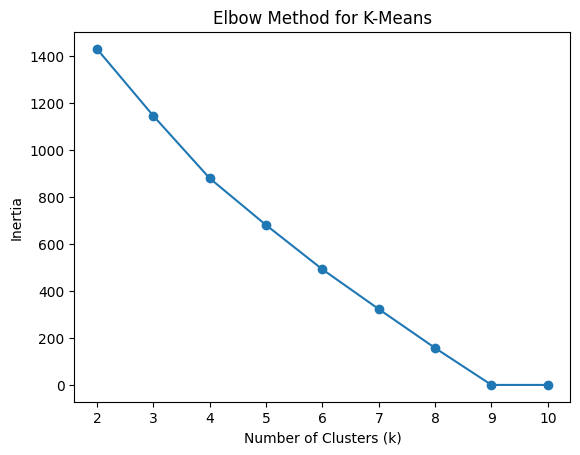

In [ ]:
import matplotlib.pyplot as plt

k_values = range(2, 11)

plt.plot(k_values, inertia, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for K-Means")
plt.show()

In [ ]:
# Silhouette analysis

In [ ]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X)

    score = silhouette_score(X, cluster_labels)
    silhouette_scores.append(score)

    print("k =", k, "Silhouette Score =", score)

k = 2 Silhouette Score = 0.2732121031966425
k = 3 Silhouette Score = 0.40442087825530315
k = 4 Silhouette Score = 0.5344500675767737
k = 5 Silhouette Score = 0.6381587579541587
k = 6 Silhouette Score = 0.73607965871094
k = 7 Silhouette Score = 0.8216465477468802
k = 8 Silhouette Score = 0.9056397666172827
k = 9 Silhouette Score = 1.0


In [ ]:
unique_texts = df_omni["cleaned_text"].nunique()

print("Total feedback rows:", len(df_omni))
print("Unique cleaned texts:", unique_texts)

Total feedback rows: 2000
Unique cleaned texts: 9


In [ ]:
print("Label counts:")
print(df_omni["label"].value_counts())

print("\nAspect category counts:")
print(df_omni["aspect_category"].value_counts())

Label counts:
label
1    1191
0     809
Name: count, dtype: int64

Aspect category counts:
aspect_category
App Crash          346
UI Ergonomics      343
General Praise     335
Billing Defect     335
Shipping Delay     326
Product Quality    315
Name: count, dtype: int64


In [ ]:
# K-Means clustering

In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)

df_omni["Cluster"] = kmeans.fit_predict(X)

print("Cluster counts:")
print(df_omni["Cluster"].value_counts().sort_index())

Cluster counts:
Cluster
0    332
1    281
2    286
3    321
4    780
Name: count, dtype: int64


In [ ]:
# Cluster interpretation

In [ ]:
terms = tfidf.get_feature_names_out()

order_centroids = kmeans.cluster_centers_.argsort()[:, ::-1]

for cluster_num in range(5):
    top_terms = [terms[ind] for ind in order_centroids[cluster_num, :10]]
    print(f"Cluster {cluster_num}:")
    print(top_terms)
    print()

Cluster 0:
['terrible', 'system', 'latency', 'after', 'latest', 'step', 'keeps', 'payment', 'crashing', 'checkout']

Cluster 1:
['packaging', 'shipping', 'nice', 'fast', 'and', 'unable', 'terrible', 'to', 'this', 'the']

Cluster 2:
['quality', 'recommended', 'product', 'great', 'highly', 'unable', 'terrible', 'to', 'this', 'the']

Cluster 3:
['very', 'smooth', 'new', 'love', 'design', 'update', 'the', 'system', 'terrible', 'unable']

Cluster 4:
['my', 'in', 'customer', 'support', 'resolved', 'minutes', 'issue', 'billing', 'to', 'outage']



In [ ]:
print(df_omni[["raw_text", "label", "aspect_category"]].head(20))

                                             raw_text  label  aspect_category
0   Customer support resolved my billing issue in ...      1        App Crash
1          Great quality product, highly recommended!      1   General Praise
2   Customer support resolved my billing issue in ...      1    UI Ergonomics
3          Great quality product, highly recommended!      1   General Praise
4   System latency is terrible after the latest up...      0  Product Quality
5   Major outage across the platform, unable to lo...      0   Billing Defect
6   Package arrived damaged and customer support i...      0  Product Quality
7          Great quality product, highly recommended!      1  Product Quality
8   Major outage across the platform, unable to lo...      0   General Praise
9                   Fast shipping and nice packaging.      1   Billing Defect
10  Package arrived damaged and customer support i...      0        App Crash
11           Love the new design update! Very smooth.      1    

In [ ]:
# 1 = Non-Critical / Positive
# 0 = Critical / Action Needed

In [ ]:
from sklearn.model_selection import train_test_split

y = df_omni["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

X_train shape: (1600, 58)
X_test shape : (400, 58)
y_train shape: (1600,)
y_test shape : (400,)


In [ ]:
# RandomForestClassifier


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report)

# Create Random Forest Classifier model
rfcmodel = RandomForestClassifier(n_estimators=100, criterion="gini", max_depth=3, min_samples_split=6, min_samples_leaf=3, random_state=42)

# Train the model
rfcmodel.fit(X_train, y_train)

# Predict
y_pred = rfcmodel.predict(X_test)

# Print predictions
print("y_pred:", y_pred[:20])

# Evaluation metrics
acc = accuracy_score(y_test, y_pred)
pre = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
cr = classification_report(y_test, y_pred)

print("\nAccuracy :", acc)
print("Precision:", pre)
print("Recall   :", rec)
print("F1 Score :", f1)
print("Confusion Matrix:\n", cm)
print("Classification Report:\n", cr)

# Training and testing accuracy
train_acc = rfcmodel.score(X_train, y_train)
test_acc = rfcmodel.score(X_test, y_test)

print("Train Accuracy:", train_acc)
print("Test Accuracy :", test_acc)

y_pred: [1 1 0 0 1 0 1 1 1 1 1 1 1 1 1 0 0 0 0 1]

Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0
Confusion Matrix:
 [[162   0]
 [  0 238]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       162
           1       1.00      1.00      1.00       238

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400

Train Accuracy: 1.0
Test Accuracy : 1.0


In [ ]:
# LogisticRegression Model

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report)

# Create Logistic Regression model
logmodel = LogisticRegression(random_state=42, class_weight="balanced")

# Train the model
logmodel.fit(X_train, y_train)

# Predict
y_pred = logmodel.predict(X_test)

# Print predictions
print("y_pred:", y_pred[:20])

# Evaluation metrics
acc_score = accuracy_score(y_test, y_pred)
pre_score = precision_score(y_test, y_pred)
rec_score = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print("\nAccuracy :", acc_score)
print("Precision:", pre_score)
print("Recall   :", rec_score)
print("F1 Score :", f1)
print("Confusion Matrix:\n", cm)
print("Classification Report:\n", class_report)

# Training and testing accuracy
train_acc = logmodel.score(X_train, y_train)
test_acc = logmodel.score(X_test, y_test)

print("Train Accuracy:", train_acc)
print("Test Accuracy :", test_acc)

y_pred: [1 1 0 0 1 0 1 1 1 1 1 1 1 1 1 0 0 0 0 1]

Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0
Confusion Matrix:
 [[162   0]
 [  0 238]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       162
           1       1.00      1.00      1.00       238

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400

Train Accuracy: 1.0
Test Accuracy : 1.0


In [ ]:
# Saving all the files (pkl)

In [ ]:
import pickle
import os

MODEL_DIR = "/content/drive/MyDrive/FINAL_PROJECT_GUVI"

# Save TF-IDF Vectorizer
with open(os.path.join(MODEL_DIR, "tfidf.pkl"), "wb") as f:
    pickle.dump(tfidf, f)

# Save K-Means model
with open(os.path.join(MODEL_DIR, "kmeans.pkl"), "wb") as f:
    pickle.dump(kmeans, f)

# Save Random Forest model
with open(os.path.join(MODEL_DIR, "random_forest.pkl"), "wb") as f:
    pickle.dump(rfcmodel, f)

# Save Logistic Regression model
with open(os.path.join(MODEL_DIR, "logistic_regression.pkl"), "wb") as f:
    pickle.dump(logmodel, f)

print("All Task 2 model files saved successfully!")
print("\nSaved files:")

for filename in [
    "tfidf.pkl",
    "kmeans.pkl",
    "random_forest.pkl",
    "logistic_regression.pkl"
]:
    print(os.path.join(MODEL_DIR, filename))

All Task 2 model files saved successfully!

Saved files:
/content/drive/MyDrive/FINAL_PROJECT_GUVI/tfidf.pkl
/content/drive/MyDrive/FINAL_PROJECT_GUVI/kmeans.pkl
/content/drive/MyDrive/FINAL_PROJECT_GUVI/random_forest.pkl
/content/drive/MyDrive/FINAL_PROJECT_GUVI/logistic_regression.pkl


In [ ]:
#Re - checking the files r saved in the drive or not?

In [ ]:
import os

MODEL_DIR = "/content/drive/MyDrive/FINAL_PROJECT_GUVI"

files_to_check = [
    "tfidf.pkl",
    "kmeans.pkl",
    "random_forest.pkl",
    "logistic_regression.pkl"
]

for file in files_to_check:
    path = os.path.join(MODEL_DIR, file)

    if os.path.exists(path):
        size = os.path.getsize(path)
        print(f"✓ {file} — Saved ({size} bytes)")
    else:
        print(f"✗ {file} — NOT FOUND")

✓ tfidf.pkl — Saved (1817 bytes)
✓ kmeans.pkl — Saved (10925 bytes)
✓ random_forest.pkl — Saved (87556 bytes)
✓ logistic_regression.pkl — Saved (1193 bytes)


In [ ]:
print("Urgency score information:")
print(df_omni["urgency_score"].describe())

print("\nMinimum urgency:", df_omni["urgency_score"].min())
print("Maximum urgency:", df_omni["urgency_score"].max())
print("Missing values:", df_omni["urgency_score"].isna().sum())

Urgency score information:
count    2000.000000
mean        0.445149
std         0.316496
min         0.000000
25%         0.162525
50%         0.343800
75%         0.758700
max         0.999700
Name: urgency_score, dtype: float64

Minimum urgency: 0.0
Maximum urgency: 0.9997
Missing values: 0


In [ ]:
# Task3

In [ ]:
#preparing for  PyTorch

In [ ]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


In [ ]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
import pandas as pd

df_omni = pd.read_csv(
    "/content/drive/MyDrive/FINAL_PROJECT_GUVI/omnifeedback_raw_dataset.csv"
)

print("Shape:", df_omni.shape)
print("Columns:", df_omni.columns.tolist())

Shape: (2000, 8)
Columns: ['feedback_id', 'user_id', 'raw_text', 'channel', 'aspect_category', 'urgency_score', 'label', 'timestamp']


In [ ]:
import re

class TextCleaner:
    def __init__(self):
        print("TextCleaner is ready")

    def remove_html(self, text):
        return re.sub(r"<.*?>", "", text)

    def extract_hashtags(self, text):
        return re.findall(r"#\w+", text)

    def remove_urls(self, text):
        return re.sub(r"https?://\S+|www\.\S+", "", text)

    def remove_special_characters(self, text):
        return re.sub(r"[^a-zA-Z0-9\s]", "", text)

    def to_lowercase(self, text):
        return text.lower()

    def clean(self, text):
        text = self.remove_html(text)
        text = self.remove_urls(text)
        hashtags = self.extract_hashtags(text)
        text = self.remove_special_characters(text)
        text = self.to_lowercase(text)
        return text, hashtags


cleaner = TextCleaner()

TextCleaner is ready


In [ ]:
print("cleaner exists:", "cleaner" in globals())

cleaner exists: True


In [ ]:
# Check the text that we will use for the BiLSTM

df_omni["cleaned_text"] = df_omni["raw_text"].apply(lambda x: cleaner.clean(str(x))[0])

print("cleaned_text column created successfully!")

print("\nFirst 5 cleaned texts:")
print(df_omni["cleaned_text"].head())
print(df_omni["cleaned_text"].head())

cleaned_text column created successfully!

First 5 cleaned texts:
0    customer support resolved my billing issue in ...
1             great quality product highly recommended
2    customer support resolved my billing issue in ...
3             great quality product highly recommended
4    system latency is terrible after the latest up...
Name: cleaned_text, dtype: object
0    customer support resolved my billing issue in ...
1             great quality product highly recommended
2    customer support resolved my billing issue in ...
3             great quality product highly recommended
4    system latency is terrible after the latest up...
Name: cleaned_text, dtype: object


In [ ]:
# Tokenization

In [ ]:
import nltk
from nltk.tokenize import word_tokenize

nltk.download("punkt")
nltk.download("punkt_tab")

print("NLTK tokenizer resources are ready!")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


NLTK tokenizer resources are ready!


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [ ]:
from nltk.tokenize import word_tokenize

# Convert cleaned text into individual words/tokens
df_omni["tokens"] = df_omni["cleaned_text"].apply(
    word_tokenize
)

print("First 5 tokenized texts:")

for i in range(5):
    print(df_omni["tokens"].iloc[i])

First 5 tokenized texts:
['customer', 'support', 'resolved', 'my', 'billing', 'issue', 'in', '5', 'minutes']
['great', 'quality', 'product', 'highly', 'recommended']
['customer', 'support', 'resolved', 'my', 'billing', 'issue', 'in', '5', 'minutes']
['great', 'quality', 'product', 'highly', 'recommended']
['system', 'latency', 'is', 'terrible', 'after', 'the', 'latest', 'update']


In [ ]:
# Stopword removal

In [ ]:
from nltk.corpus import stopwords

nltk.download("stopwords")

stop_words = set(stopwords.words("english"))

# Keep important negation words for sentiment/urgency
important_words = {"no", "not", "never", "nor"}

stop_words = stop_words - important_words

print("Number of stopwords:", len(stop_words))
print("\nExample stopwords:")
print(list(stop_words)[:20])

print("\nProtected words:")
print(important_words)

Number of stopwords: 195

Example stopwords:
['yourselves', "doesn't", 'their', 'as', 'haven', 'needn', 'now', "should've", "you'll", 'me', 'your', 'above', 'of', "aren't", 'mightn', "it'll", "isn't", 'which', "she's", 'ma']

Protected words:
{'not', 'no', 'nor', 'never'}


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
df_omni["tokens"] = df_omni["tokens"].apply(
    lambda words: [word for word in words if word.lower() not in stop_words]
)

print("First 5 tokenized texts after stopword removal:")

for i in range(5):
    print(df_omni["tokens"].iloc[i])

First 5 tokenized texts after stopword removal:
['customer', 'support', 'resolved', 'billing', 'issue', '5', 'minutes']
['great', 'quality', 'product', 'highly', 'recommended']
['customer', 'support', 'resolved', 'billing', 'issue', '5', 'minutes']
['great', 'quality', 'product', 'highly', 'recommended']
['system', 'latency', 'terrible', 'latest', 'update']


In [ ]:
# punctuation

In [ ]:
import string

df_omni["tokens"] = df_omni["tokens"].apply(
    lambda words: [word for word in words if word not in string.punctuation]
)

print("First 5 tokenized texts after punctuation removal:")

for i in range(5):
    print(df_omni["tokens"].iloc[i])

First 5 tokenized texts after punctuation removal:
['customer', 'support', 'resolved', 'billing', 'issue', '5', 'minutes']
['great', 'quality', 'product', 'highly', 'recommended']
['customer', 'support', 'resolved', 'billing', 'issue', '5', 'minutes']
['great', 'quality', 'product', 'highly', 'recommended']
['system', 'latency', 'terrible', 'latest', 'update']


In [ ]:
# Lemmatization

In [ ]:
from nltk.stem import WordNetLemmatizer

nltk.download("wordnet")

lemmatizer = WordNetLemmatizer()

df_omni["tokens"] = df_omni["tokens"].apply(
    lambda words: [lemmatizer.lemmatize(word) for word in words]
)

print("First 5 tokenized texts after lemmatization:")

for i in range(5):
    print(df_omni["tokens"].iloc[i])

[nltk_data] Downloading package wordnet to /root/nltk_data...


First 5 tokenized texts after lemmatization:
['customer', 'support', 'resolved', 'billing', 'issue', '5', 'minute']
['great', 'quality', 'product', 'highly', 'recommended']
['customer', 'support', 'resolved', 'billing', 'issue', '5', 'minute']
['great', 'quality', 'product', 'highly', 'recommended']
['system', 'latency', 'terrible', 'latest', 'update']


In [ ]:
# Rebuild the vocabulary

In [ ]:
from collections import Counter

word_counts = Counter()

for tokens in df_omni["tokens"]:
    word_counts.update(tokens)

vocab = {"<PAD>": 0, "<UNK>": 1}

for word in word_counts:
    vocab[word] = len(vocab)

print("Vocabulary size:", len(vocab))
print("\nFirst 20 vocabulary items:")
print(list(vocab.items())[:20])

Vocabulary size: 50

First 20 vocabulary items:
[('<PAD>', 0), ('<UNK>', 1), ('customer', 2), ('support', 3), ('resolved', 4), ('billing', 5), ('issue', 6), ('5', 7), ('minute', 8), ('great', 9), ('quality', 10), ('product', 11), ('highly', 12), ('recommended', 13), ('system', 14), ('latency', 15), ('terrible', 16), ('latest', 17), ('update', 18), ('major', 19)]


In [ ]:
# Convert each word in our cleaned text into the numerical ID that assigned in our vocabulary.
# This is the numerical representation that we will eventually give to the BiLSTM

In [ ]:
def tokens_to_sequence(tokens):
    sequence = []

    for word in tokens:
        if word in vocab:
            sequence.append(vocab[word])
        else:
            sequence.append(vocab["<UNK>"])

    return sequence


df_omni["sequence"] = df_omni["tokens"].apply(tokens_to_sequence)

print("First 5 numerical sequences:")

for i in range(5):
    print(df_omni["sequence"].iloc[i])

First 5 numerical sequences:
[2, 3, 4, 5, 6, 7, 8]
[9, 10, 11, 12, 13]
[2, 3, 4, 5, 6, 7, 8]
[9, 10, 11, 12, 13]
[14, 15, 16, 17, 18]


In [ ]:
df_omni["sequence_length"] = df_omni["sequence"].apply(len)

print("Sequence length statistics:")
print(df_omni["sequence_length"].describe())

print("\nMinimum length:", df_omni["sequence_length"].min())
print("Maximum length:", df_omni["sequence_length"].max())

Sequence length statistics:
count    2000.000000
mean        5.556000
std         0.993155
min         4.000000
25%         5.000000
50%         5.000000
75%         6.000000
max         7.000000
Name: sequence_length, dtype: float64

Minimum length: 4
Maximum length: 7


In [ ]:
# Padding
# makes all sentences the same length

In [ ]:
MAX_LEN = 7

def pad_or_truncate(sequence, max_len):
    if len(sequence) < max_len:
        sequence = sequence + [vocab["<PAD>"]] * (max_len - len(sequence))
    else:
        sequence = sequence[:max_len]

    return sequence


df_omni["padded_sequence"] = df_omni["sequence"].apply(
    lambda x: pad_or_truncate(x, MAX_LEN)
)

print("First 5 padded sequences:")

for i in range(5):
    print(df_omni["padded_sequence"].iloc[i])

First 5 padded sequences:
[2, 3, 4, 5, 6, 7, 8]
[9, 10, 11, 12, 13, 0, 0]
[2, 3, 4, 5, 6, 7, 8]
[9, 10, 11, 12, 13, 0, 0]
[14, 15, 16, 17, 18, 0, 0]


In [ ]:
# Create the PyTorch Dataset

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader

class FeedbackDataset(Dataset):

    def __init__(self, sequences, targets):
        self.sequences = torch.tensor(sequences, dtype=torch.long)
        self.targets = torch.tensor(targets, dtype=torch.float32)

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        return self.sequences[idx], self.targets[idx]

In [ ]:
X_sequences = df_omni["padded_sequence"].tolist()
y_urgency = df_omni["urgency_score"].tolist()

print("Number of sequences:", len(X_sequences))
print("Number of urgency scores:", len(y_urgency))

print("\nFirst sequence:", X_sequences[0])
print("First urgency score:", y_urgency[0])

Number of sequences: 2000
Number of urgency scores: 2000

First sequence: [2, 3, 4, 5, 6, 7, 8]
First urgency score: 0.3448


In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Train / Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_sequences,
    y_urgency,
    test_size=0.2,
    random_state=42
)

# Dataset
class FeedbackDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, index):
        return self.X[index], self.y[index]

train_dataset = FeedbackDataset(X_train, y_train)
test_dataset = FeedbackDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# BiLSTM Model
class BiLSTM(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()

        self.embedding = nn.Embedding(
            vocab_size, 64, padding_idx=0
        )

        self.lstm = nn.LSTM(
            64, 64,
            batch_first=True,
            bidirectional=True
        )

        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(128, 1)

    def forward(self, x):
        x = self.embedding(x)
        _, (hidden, _) = self.lstm(x)

        x = torch.cat(
            (hidden[-2], hidden[-1]),
            dim=1
        )

        x = self.dropout(x)
        x = self.fc(x)

        return torch.sigmoid(x).squeeze(1)

# Model
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = BiLSTM(len(vocab)).to(device)

# Loss and Optimizer
criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-5
)

# Training
for epoch in range(20):

    model.train()

    for X_batch, y_batch in train_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        predictions = model(X_batch)

        loss = criterion(predictions, y_batch)

        loss.backward()
        optimizer.step()

    print(
        f"Epoch {epoch+1}/20, Loss: {loss.item():.4f}"
    )

# Evaluation
model.eval()

predictions = []
actual = []

with torch.no_grad():

    for X_batch, y_batch in test_loader:

        X_batch = X_batch.to(device)

        output = model(X_batch)

        predictions.extend(output.cpu().numpy())
        actual.extend(y_batch.numpy())

mse = mean_squared_error(actual, predictions)
rmse = np.sqrt(mse)
mae = mean_absolute_error(actual, predictions)

print("\nEvaluation Metrics")
print("MSE  :", mse)
print("RMSE :", rmse)
print("MAE  :", mae)

Epoch 1/20, Loss: 0.0157
Epoch 2/20, Loss: 0.0132
Epoch 3/20, Loss: 0.0161
Epoch 4/20, Loss: 0.0137
Epoch 5/20, Loss: 0.0129
Epoch 6/20, Loss: 0.0131
Epoch 7/20, Loss: 0.0190
Epoch 8/20, Loss: 0.0171
Epoch 9/20, Loss: 0.0181
Epoch 10/20, Loss: 0.0128
Epoch 11/20, Loss: 0.0157
Epoch 12/20, Loss: 0.0161
Epoch 13/20, Loss: 0.0131
Epoch 14/20, Loss: 0.0144
Epoch 15/20, Loss: 0.0103
Epoch 16/20, Loss: 0.0195
Epoch 17/20, Loss: 0.0146
Epoch 18/20, Loss: 0.0168
Epoch 19/20, Loss: 0.0140
Epoch 20/20, Loss: 0.0149

Evaluation Metrics
MSE  : 0.01314558178692443
RMSE : 0.11465418346891852
MAE  : 0.0985081885411637


In [ ]:
import os
import torch

MODEL_PATH = "/content/drive/MyDrive/FINAL_PROJECT_GUVI/bilstm_urgency.pth"

torch.save(
    {
        "model_state_dict": model.state_dict(),
        "vocab": vocab,
        "max_len": MAX_LEN,
        "embedding_dim": 64,
        "hidden_dim": 64
    },
    MODEL_PATH
)

print("BiLSTM model saved successfully!")
print("File:", MODEL_PATH)
print("File exists:", os.path.exists(MODEL_PATH))

BiLSTM model saved successfully!
File: /content/drive/MyDrive/FINAL_PROJECT_GUVI/bilstm_urgency.pth
File exists: True


In [ ]:
# Task4  BERT NER

In [ ]:
from transformers import pipeline

ner_pipeline = pipeline(
    "ner",
    model="dslim/bert-base-NER",
    aggregation_strategy="simple",
    device=0 if torch.cuda.is_available() else -1
)

print("BERT NER model loaded successfully!")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForTokenClassification LOAD REPORT from: dslim/bert-base-NER
Key                      | Status     |  | 
-------------------------+------------+--+-
bert.pooler.dense.bias   | UNEXPECTED |  | 
bert.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BERT NER model loaded successfully!


In [ ]:
text = df_omni["raw_text"].iloc[0]

entities = ner_pipeline(text)

print("Feedback:")
print(text)

print("\nNamed Entities:")
print(entities)

Feedback:
Customer support resolved my billing issue in 5 minutes.

Named Entities:
[]


In [ ]:
# Testing NER

In [ ]:
test_text = "Microsoft support is not working in Hyderabad."

entities = ner_pipeline(test_text)

print("Feedback:")
print(test_text)

print("\nNamed Entities:")
print(entities)

Feedback:
Microsoft support is not working in Hyderabad.

Named Entities:
[{'entity_group': 'ORG', 'score': np.float32(0.99728584), 'word': 'Microsoft', 'start': 0, 'end': 9}, {'entity_group': 'LOC', 'score': np.float32(0.9991947), 'word': 'Hyderabad', 'start': 36, 'end': 45}]


In [ ]:
# Apply BERT NER to our OmniFeedback dataset

In [ ]:
df_omni["entities"] = df_omni["raw_text"].apply(ner_pipeline)

print(df_omni[["raw_text", "entities"]].head())

                                            raw_text entities
0  Customer support resolved my billing issue in ...       []
1         Great quality product, highly recommended!       []
2  Customer support resolved my billing issue in ...       []
3         Great quality product, highly recommended!       []
4  System latency is terrible after the latest up...       []


In [ ]:
# BART summarization

In [ ]:
import transformers

print(transformers.__version__)

5.16.1


In [ ]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

model_name = "facebook/bart-large-cnn"

tokenizer = AutoTokenizer.from_pretrained(model_name)
bart_model = AutoModelForSeq2SeqLM.from_pretrained(model_name).to(device)

print("BART model loaded successfully!")

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.63GB            

model.safetensors: downloading bytes:           |  0.00B            

[transformers] Please make sure the generation config includes `forced_bos_token_id=0`. 


Loading weights:   0%|          | 0/511 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

BART model loaded successfully!


In [ ]:
# Hugging Face = the platform/hub where we download and use the model.
# facebook = the model owner's namespace on Hugging Face.
# bart-large-cnn = the specific model

In [ ]:
# Testing  BART on a passage,

In [ ]:
text = """The customer reported that the latest application update caused
severe system latency. They said the application takes several minutes to
load important pages and sometimes becomes completely unresponsive.
The customer is unable to complete their work efficiently and requested
an urgent solution from the technical support team."""

inputs = tokenizer(text, return_tensors="pt", truncation=True).to(device)

summary_ids = bart_model.generate(
    **inputs,
    max_length=50,
    min_length=15,
    num_beams=4,
    early_stopping=True
)

summary = tokenizer.decode(summary_ids[0], skip_special_tokens=True)

print("Original:")
print(text)

print("\nSummary:")
print(summary)

Original:
The customer reported that the latest application update caused
severe system latency. They said the application takes several minutes to
load important pages and sometimes becomes completely unresponsive.
The customer is unable to complete their work efficiently and requested
an urgent solution from the technical support team.

Summary:
The customer reported that the latest application update causedsevere system latency. They said the application takes several minutes toload important pages and sometimes becomes completely unresponsive.


In [ ]:
df_omni["text_length"] = df_omni["raw_text"].str.len()

print(df_omni["text_length"].describe())

count    2000.000000
mean       47.471500
std         9.465568
min        33.000000
25%        40.000000
50%        48.000000
75%        55.000000
max        67.000000
Name: text_length, dtype: float64


In [ ]:
# Task 5 — GenAI Intelligence Copilot

In [ ]:
print(df_omni.columns.tolist())

['feedback_id', 'user_id', 'raw_text', 'channel', 'aspect_category', 'urgency_score', 'label', 'timestamp', 'cleaned_text', 'tokens', 'sequence', 'sequence_length', 'padded_sequence', 'entities', 'text_length']


In [ ]:
def copilot(feedback_text, urgency_score, entities, summary):

    if urgency_score >= 0.7:
        priority = "High"
        action = "Escalate to support team immediately"

    elif urgency_score >= 0.4:
        priority = "Medium"
        action = "Review and assign to support team"

    else:
        priority = "Low"
        action = "Monitor feedback"

    result = {
        "feedback": feedback_text,
        "urgency_score": round(float(urgency_score), 2),
        "priority": priority,
        "entities": entities,
        "summary": summary,
        "recommended_action": action
    }

    return result

In [ ]:
result = copilot(
    df_omni.loc[0, "raw_text"],
    df_omni.loc[0, "urgency_score"],
    df_omni.loc[0, "entities"],
    "Customer reported an issue with the service."
)

print(result)

{'feedback': 'Customer support resolved my billing issue in 5 minutes.', 'urgency_score': 0.34, 'priority': 'Low', 'entities': [], 'summary': 'Customer reported an issue with the service.', 'recommended_action': 'Monitor feedback'}


In [ ]:
text = df_omni.loc[0, "raw_text"]

inputs = tokenizer(text,return_tensors="pt",truncation=True).to(device)

summary_ids = bart_model.generate(**inputs, max_length=50, min_length=5, num_beams=4, early_stopping=True)

summary = tokenizer.decode(summary_ids[0], skip_special_tokens=True)

print("Original:")
print(text)

print("\nBART Summary:")
print(summary)

Original:
Customer support resolved my billing issue in 5 minutes.

BART Summary:
Customer support resolved my billing issue in 5 minutes.


In [ ]:
# Use the BART summary in the Copilot

In [ ]:
result = copilot(text, df_omni.loc[0, "urgency_score"], df_omni.loc[0, "entities"], summary)

print(result)

{'feedback': 'Customer support resolved my billing issue in 5 minutes.', 'urgency_score': 0.34, 'priority': 'Low', 'entities': [], 'summary': 'Customer support resolved my billing issue in 5 minutes.', 'recommended_action': 'Monitor feedback'}


In [ ]:
# Convert the Copilot result to JSON

In [ ]:
import json

json_output = json.dumps(result, indent=4)

print(json_output)

{
    "feedback": "Customer support resolved my billing issue in 5 minutes.",
    "urgency_score": 0.34,
    "priority": "Low",
    "entities": [],
    "summary": "Customer support resolved my billing issue in 5 minutes.",
    "recommended_action": "Monitor feedback"
}
